<a href="https://colab.research.google.com/github/mohansharma077/amr_mobilenet/blob/main/Explainability_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explainable AI for Bacterial AST Classification

Grad-CAM visualization and quantitative feature analysis to understand what morphological features the deep learning models use for resistance classification.

Expected outputs:
- Grad-CAM heatmaps showing model attention
- Quantitative feature analysis
- Statistical comparison between resistant and susceptible cells
- Biological validation of learned features

## Part 1: Setup

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
from scipy import stats
from scipy.ndimage import center_of_mass
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

TensorFlow version: 2.19.0
NumPy version: 2.0.2


In [6]:
# Configuration
BASE_PATH = '/content/drive/MyDrive/amr'
RESULTS_DIR = Path(BASE_PATH) / 'full_training_results'
XAI_DIR = Path(BASE_PATH) / 'explainability_results'

XAI_DIR.mkdir(exist_ok=True)
(XAI_DIR / 'figures').mkdir(exist_ok=True)
(XAI_DIR / 'features').mkdir(exist_ok=True)

# Which model to analyze
MODEL_NAME = 'mobilenet'

print(f"Results directory: {RESULTS_DIR}")
print(f"XAI output directory: {XAI_DIR}")
print(f"Analyzing model: {MODEL_NAME}")

Results directory: /content/drive/MyDrive/amr/full_training_results
XAI output directory: /content/drive/MyDrive/amr/explainability_results
Analyzing model: mobilenet


## Part 2: Load Data and Model

In [7]:
# Load test data
dataset = np.load(RESULTS_DIR / 'full_dataset_30k.npz')
X = dataset['images']
y = dataset['labels']

# Get test split
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

X_test = X_test.astype('float32') / 255.0

print(f"Test set: {len(X_test)} images")
print(f"Resistant: {np.sum(y_test==0)}")
print(f"Susceptible: {np.sum(y_test==1)}")

Test set: 4500 images
Resistant: 2250
Susceptible: 2250


In [8]:
# Load trained model
model_path = RESULTS_DIR / 'models' / f'{MODEL_NAME}_best.h5'
model = tf.keras.models.load_model(model_path)

print(f"Loaded model: {model_path}")
print(f"Model layers: {len(model.layers)}")

Loaded model: /content/drive/MyDrive/amr/full_training_results/models/mobilenet_best.h5
Model layers: 159


## Part 3: Grad-CAM Implementation

In [10]:
class GradCAM:
    def __init__(self, model, layer_name=None):
        """
        Grad-CAM implementation

        """
        self.model = model
        self.layer_name = layer_name or self._find_target_layer()
        self.grad_model = self._build_grad_model()

        print(f"Using layer: {self.layer_name}")

    def _find_target_layer(self):
        """Find the last convolutional layer"""
        for layer in reversed(self.model.layers):
            if 'conv' in layer.name.lower():
                return layer.name
        raise ValueError("No convolutional layer found in model")

    def _build_grad_model(self):
        """Build model for gradient computation"""
        target_layer = self.model.get_layer(self.layer_name)
        grad_model = Model(
            inputs=[self.model.inputs],
            outputs=[target_layer.output, self.model.output]
        )
        return grad_model

    def generate_heatmap(self, img, class_idx):
        """
        Generate Grad-CAM heatmap

        Args:
            img: Input image (H, W, C)
            class_idx: Target class index

        Returns:
            heatmap: Grad-CAM heatmap (H, W)
        """
        img_array = np.expand_dims(img, axis=0)

        with tf.GradientTape() as tape:
            conv_outputs, predictions = self.grad_model(img_array)
            loss = predictions[:, class_idx]

        # Compute gradients
        grads = tape.gradient(loss, conv_outputs)

        # Global average pooling of gradients
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

        # Weight feature maps by gradients
        conv_outputs = conv_outputs[0]
        heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)

        # Normalize heatmap
        heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
        heatmap = heatmap.numpy()

        # Resize to original image size
        heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

        return heatmap

    def visualize(self, img, heatmap, alpha=0.4):
        """
        Create overlay visualization

        Args:
            img: Original image (H, W, C)
            heatmap: Grad-CAM heatmap (H, W)
            alpha: Overlay transparency

        Returns:
            superimposed: Overlay image
        """
        # Convert heatmap to RGB
        heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

        # Convert original image to uint8
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)

        # Superimpose
        superimposed = cv2.addWeighted(img, 1-alpha, heatmap_colored, alpha, 0)

        return superimposed

# Initialize Grad-CAM
gradcam = GradCAM(model)
print("Grad-CAM initialized")

Using layer: Conv_1_bn
Grad-CAM initialized


## Part 4: Generate Grad-CAM Heatmaps

In [11]:
# Select samples for visualization
n_samples_per_class = 100

resistant_indices = np.where(y_test == 0)[0]
susceptible_indices = np.where(y_test == 1)[0]

sample_resistant = np.random.choice(resistant_indices, n_samples_per_class, replace=False)
sample_susceptible = np.random.choice(susceptible_indices, n_samples_per_class, replace=False)

print(f"Selected {n_samples_per_class} samples per class for analysis")

Selected 100 samples per class for analysis


In [12]:
# Generate heatmaps for all samples
from tqdm import tqdm
import types

# Define a patched version of generate_heatmap
def patched_generate_heatmap(self, img, class_idx):
    img_array = np.expand_dims(img, axis=0)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = self.grad_model(img_array)

        # Ensure predictions is a tensor, in case it's wrapped in a list
        if isinstance(predictions, list):
            if len(predictions) > 0:
                predictions = predictions[0]
            else:
                # This case should ideally not happen if model output is consistent
                raise ValueError("Predictions list is empty.")

        # Access the loss for the target class from the single batch item
        # For a batch size of 1, predictions will be of shape (1, num_classes)
        loss = predictions[0, class_idx]

    # Compute gradients
    grads = tape.gradient(loss, conv_outputs)

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight feature maps by gradients
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    # Resize to original image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    return heatmap

# Dynamically replace the method on the existing gradcam instance
gradcam.generate_heatmap = types.MethodType(patched_generate_heatmap, gradcam)

heatmaps_resistant = []
heatmaps_susceptible = []

print("Generating heatmaps for resistant cells...")
for idx in tqdm(sample_resistant):
    img = X_test[idx]
    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)
    predicted_class = np.argmax(pred)
    heatmap = gradcam.generate_heatmap(img, predicted_class)
    heatmaps_resistant.append(heatmap)

print("Generating heatmaps for susceptible cells...")
for idx in tqdm(sample_susceptible):
    img = X_test[idx]
    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)
    predicted_class = np.argmax(pred)
    heatmap = gradcam.generate_heatmap(img, predicted_class)
    heatmaps_susceptible.append(heatmap)

heatmaps_resistant = np.array(heatmaps_resistant)
heatmaps_susceptible = np.array(heatmaps_susceptible)

print(f"Generated {len(heatmaps_resistant)} resistant heatmaps")
print(f"Generated {len(heatmaps_susceptible)} susceptible heatmaps")

Generating heatmaps for resistant cells...


100%|██████████| 100/100 [00:48<00:00,  2.07it/s]


Generating heatmaps for susceptible cells...


100%|██████████| 100/100 [00:46<00:00,  2.16it/s]

Generated 100 resistant heatmaps
Generated 100 susceptible heatmaps


## Part 5: Feature Extraction from Heatmaps

In [13]:
class BiologicalFeatureExtractor:
    """
    Extract quantitative features from images and heatmaps
    """

    @staticmethod
    def extract_features(img, heatmap, mask=None):
        """
        Extract morphological and attention features

        Args:
            img: Original image (H, W, 3)
            heatmap: Grad-CAM heatmap (H, W)
            mask: Binary mask (optional)

        Returns:
            features: Dictionary of extracted features
        """
        if mask is None:
            # Create simple mask from image intensity
            gray = np.mean(img, axis=2)
            mask = gray > (gray.mean() * 0.5)

        features = {}

        # Attention features
        features['attention_mean'] = np.mean(heatmap[mask])
        features['attention_max'] = np.max(heatmap[mask])
        features['attention_std'] = np.std(heatmap[mask])
        features['attention_spread'] = np.std(heatmap[mask]) / (np.mean(heatmap[mask]) + 1e-7)

        # Channel intensity features
        nile_red = img[:, :, 0]  # Membrane
        dapi = img[:, :, 1]      # DNA

        features['nile_red_mean'] = np.mean(nile_red[mask])
        features['dapi_mean'] = np.mean(dapi[mask])
        features['dapi_nile_red_ratio'] = features['dapi_mean'] / (features['nile_red_mean'] + 1e-7)

        # Attention on channels
        dapi_mask = dapi > np.percentile(dapi[mask], 75)
        features['attention_on_dapi'] = np.mean(heatmap[dapi_mask & mask])

        nile_red_mask = nile_red > np.percentile(nile_red[mask], 75)
        features['attention_on_membrane'] = np.mean(heatmap[nile_red_mask & mask])

        # Morphological features
        contours, _ = cv2.findContours(
            mask.astype(np.uint8),
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        if contours:
            cnt = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(cnt)
            perimeter = cv2.arcLength(cnt, True)

            features['area'] = area
            features['perimeter'] = perimeter
            features['circularity'] = 4 * np.pi * area / (perimeter**2 + 1e-7)

            # Aspect ratio
            if len(cnt) >= 5:
                ellipse = cv2.fitEllipse(cnt)
                major_axis = max(ellipse[1])
                minor_axis = min(ellipse[1])
                features['aspect_ratio'] = major_axis / (minor_axis + 1e-7)
            else:
                features['aspect_ratio'] = 1.0
        else:
            features['area'] = 0
            features['perimeter'] = 0
            features['circularity'] = 0
            features['aspect_ratio'] = 1.0

        # Spatial features
        cy, cx = center_of_mass(heatmap * mask)
        features['attention_center_y'] = cy / img.shape[0]
        features['attention_center_x'] = cx / img.shape[1]

        return features

extractor = BiologicalFeatureExtractor()
print("Feature extractor initialized")

Feature extractor initialized


In [14]:
# Extract features for all samples
print("Extracting features from resistant cells...")
features_resistant = []
for idx, heatmap in zip(sample_resistant, heatmaps_resistant):
    img = X_test[idx]
    features = extractor.extract_features(img, heatmap)
    features_resistant.append(features)

print("Extracting features from susceptible cells...")
features_susceptible = []
for idx, heatmap in zip(sample_susceptible, heatmaps_susceptible):
    img = X_test[idx]
    features = extractor.extract_features(img, heatmap)
    features_susceptible.append(features)

# Convert to DataFrames
df_resistant = pd.DataFrame(features_resistant)
df_resistant['class'] = 'resistant'

df_susceptible = pd.DataFrame(features_susceptible)
df_susceptible['class'] = 'susceptible'

df_features = pd.concat([df_resistant, df_susceptible], ignore_index=True)

print(f"\nExtracted {len(df_features.columns)-1} features")
print(f"Total samples: {len(df_features)}")

Extracting features from resistant cells...
Extracting features from susceptible cells...

Extracted 15 features
Total samples: 200


In [15]:
# Save features
df_features.to_csv(XAI_DIR / 'features' / 'extracted_features.csv', index=False)
print(f"Features saved to {XAI_DIR / 'features' / 'extracted_features.csv'}")

Features saved to /content/drive/MyDrive/amr/explainability_results/features/extracted_features.csv


## Part 6: Statistical Analysis

In [16]:
# Perform Mann-Whitney U test for each feature
feature_names = [col for col in df_features.columns if col != 'class']

results = []
for feature in feature_names:
    resistant_vals = df_features[df_features['class'] == 'resistant'][feature].values
    susceptible_vals = df_features[df_features['class'] == 'susceptible'][feature].values

    # Remove NaN values
    resistant_vals = resistant_vals[~np.isnan(resistant_vals)]
    susceptible_vals = susceptible_vals[~np.isnan(susceptible_vals)]

    if len(resistant_vals) > 0 and len(susceptible_vals) > 0:
        statistic, pvalue = stats.mannwhitneyu(resistant_vals, susceptible_vals, alternative='two-sided')

        results.append({
            'feature': feature,
            'resistant_mean': np.mean(resistant_vals),
            'resistant_std': np.std(resistant_vals),
            'susceptible_mean': np.mean(susceptible_vals),
            'susceptible_std': np.std(susceptible_vals),
            'statistic': statistic,
            'p_value': pvalue,
            'significant': pvalue < 0.05
        })

df_stats = pd.DataFrame(results)
df_stats = df_stats.sort_values('p_value')

print("\nStatistical Significance Test Results:")
print(df_stats.to_string(index=False))

# Save statistics
df_stats.to_csv(XAI_DIR / 'features' / 'statistical_analysis.csv', index=False)
print(f"\nStatistical results saved")


Statistical Significance Test Results:
            feature  resistant_mean  resistant_std  susceptible_mean  susceptible_std  statistic      p_value  significant
      attention_max        0.802965       0.263017          0.961037         0.153249     2023.5 4.263737e-16         True
     attention_mean        0.677341       0.268322          0.861024         0.155828     2537.5 1.791458e-09         True
      nile_red_mean        0.804964       0.045865          0.787353         0.039575     6188.0 3.713520e-03         True
dapi_nile_red_ratio        0.987596       0.103850          0.962310         0.196886     6139.0 5.405516e-03         True
 attention_center_y        0.200448       0.063582          0.178060         0.049691     5798.0 1.212464e-02         True
          dapi_mean        0.795001       0.092425          0.757757         0.159274     6024.0 1.239036e-02         True
               area      722.715000     381.365705        619.950000       272.813466     5878.0 3.

In [17]:
# Display significant features
significant_features = df_stats[df_stats['significant']]

print(f"\nSignificant features (p < 0.05): {len(significant_features)}")
print("\nTop 5 most significant features:")
print(significant_features.head()[['feature', 'p_value']].to_string(index=False))


Significant features (p < 0.05): 8

Top 5 most significant features:
            feature      p_value
      attention_max 4.263737e-16
     attention_mean 1.791458e-09
      nile_red_mean 3.713520e-03
dapi_nile_red_ratio 5.405516e-03
 attention_center_y 1.212464e-02


## Part 7: Visualizations

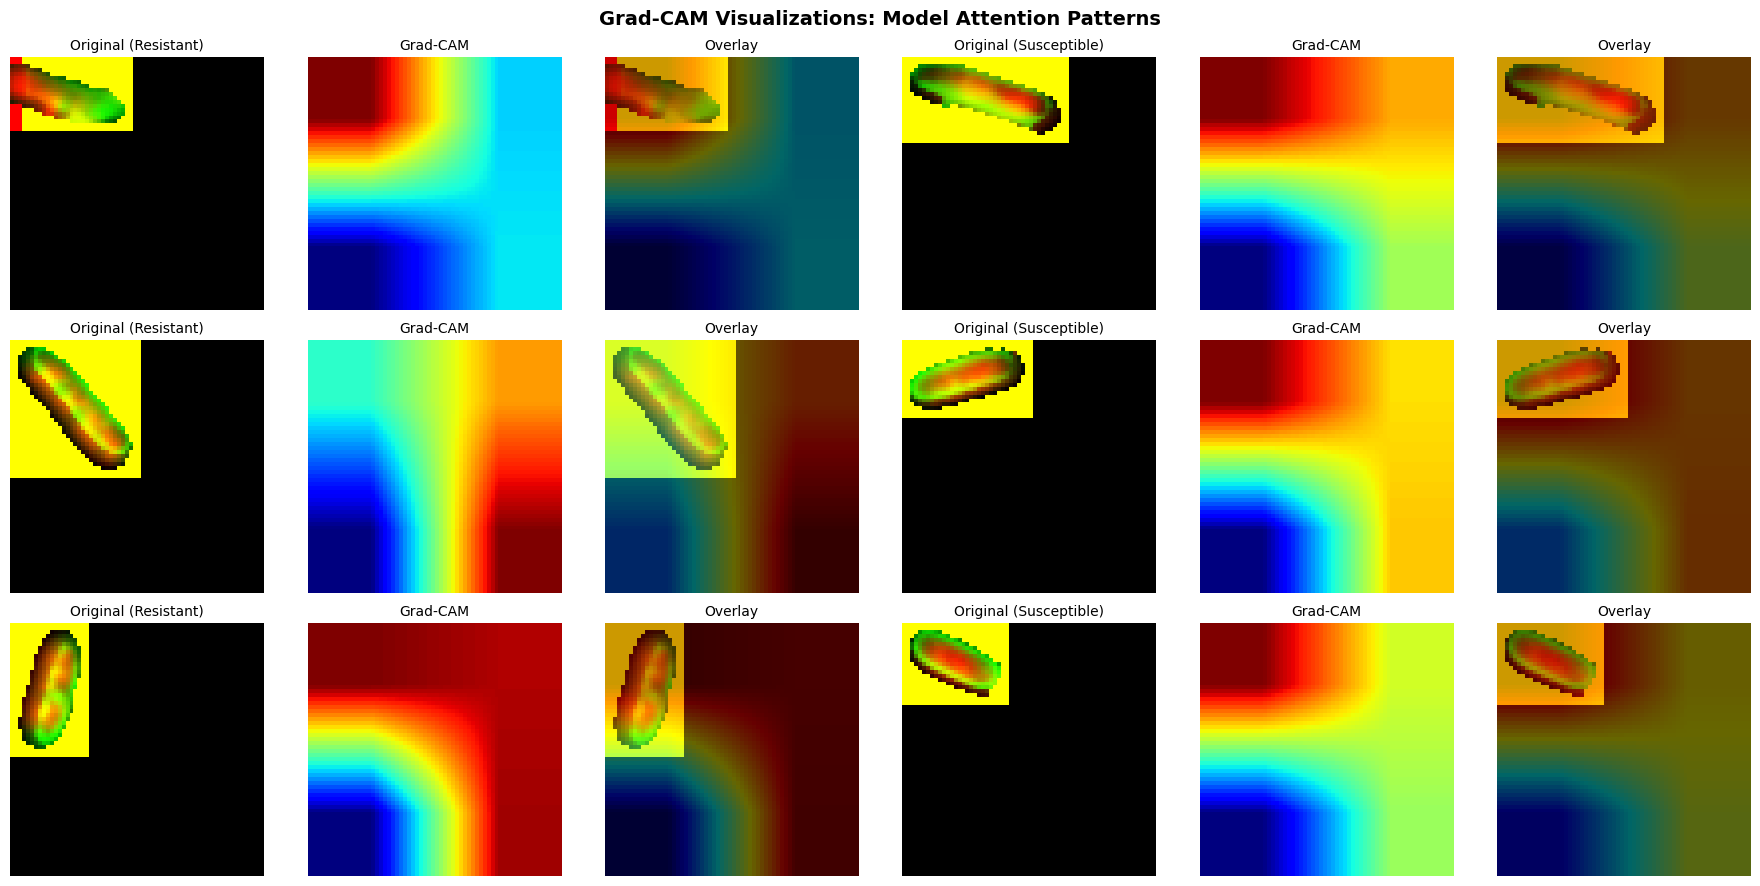

Example visualizations saved


In [18]:
# Figure 1: Example Grad-CAM visualizations
fig, axes = plt.subplots(3, 6, figsize=(18, 9))

# Select 3 examples per class
example_resistant = sample_resistant[:3]
example_susceptible = sample_susceptible[:3]

for i, idx in enumerate(example_resistant):
    img = X_test[idx]
    heatmap = heatmaps_resistant[i]
    overlay = gradcam.visualize(img, heatmap)

    # Original
    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Original (Resistant)', fontsize=10)
    axes[i, 0].axis('off')

    # Heatmap
    axes[i, 1].imshow(heatmap, cmap='jet')
    axes[i, 1].set_title('Grad-CAM', fontsize=10)
    axes[i, 1].axis('off')

    # Overlay
    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title('Overlay', fontsize=10)
    axes[i, 2].axis('off')

for i, idx in enumerate(example_susceptible):
    img = X_test[idx]
    heatmap = heatmaps_susceptible[i]
    overlay = gradcam.visualize(img, heatmap)

    # Original
    axes[i, 3].imshow(img)
    axes[i, 3].set_title('Original (Susceptible)', fontsize=10)
    axes[i, 3].axis('off')

    # Heatmap
    axes[i, 4].imshow(heatmap, cmap='jet')
    axes[i, 4].set_title('Grad-CAM', fontsize=10)
    axes[i, 4].axis('off')

    # Overlay
    axes[i, 5].imshow(overlay)
    axes[i, 5].set_title('Overlay', fontsize=10)
    axes[i, 5].axis('off')

plt.suptitle('Grad-CAM Visualizations: Model Attention Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(XAI_DIR / 'figures' / 'gradcam_examples.png', dpi=300, bbox_inches='tight')
plt.show()

print("Example visualizations saved")

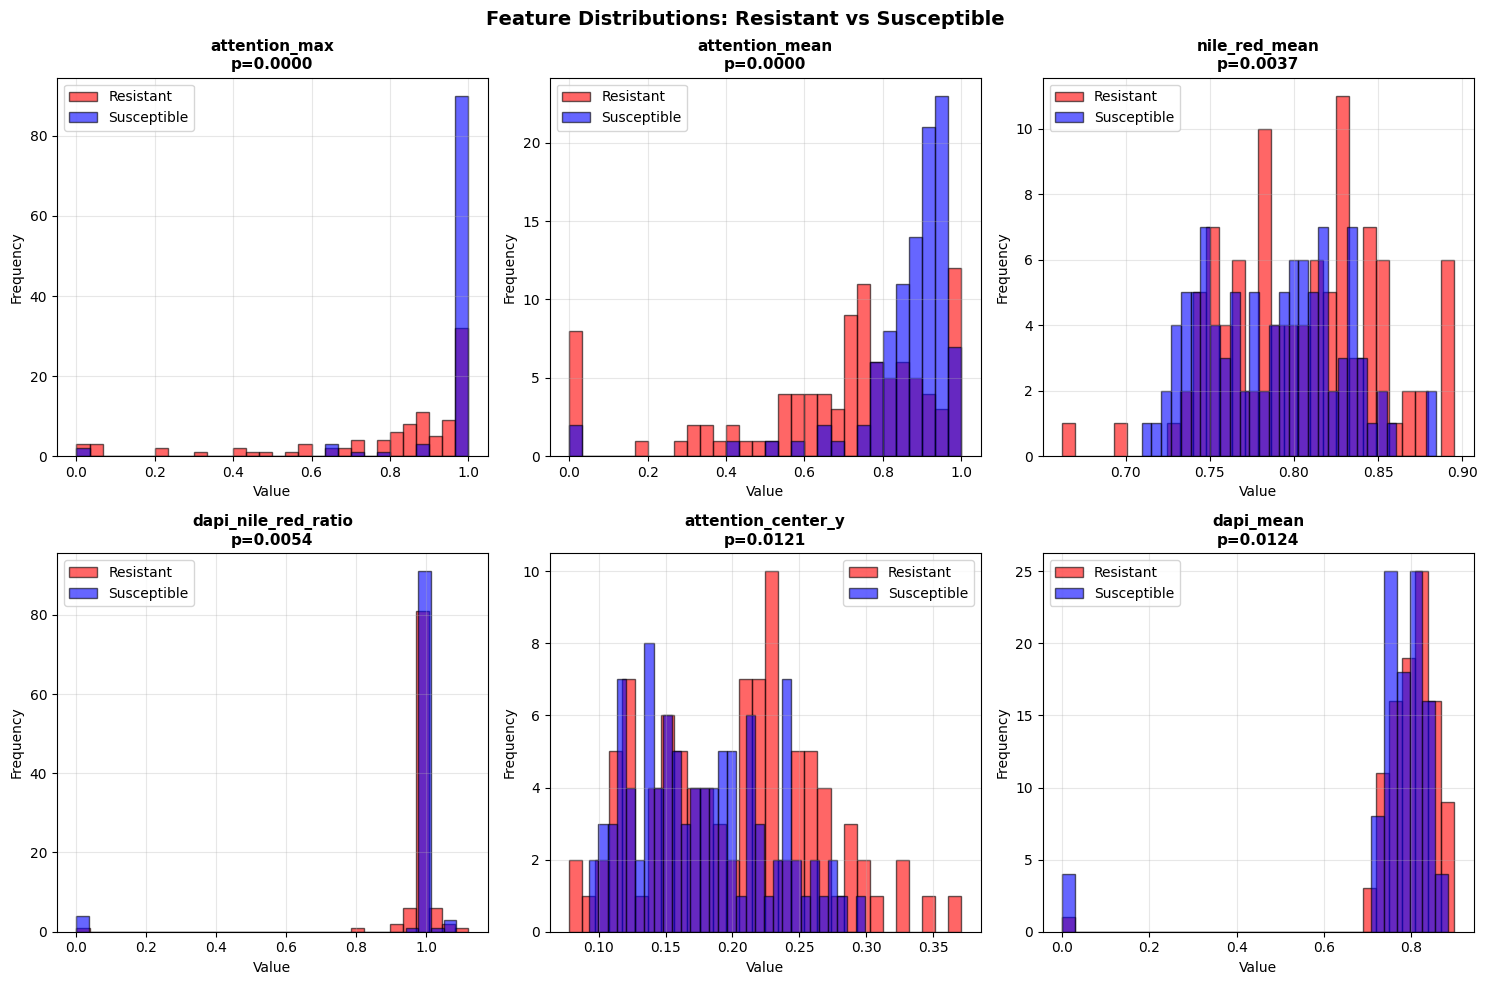

Feature distributions saved


In [19]:
# Figure 2: Feature distributions
top_features = significant_features.head(6)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    resistant_vals = df_features[df_features['class'] == 'resistant'][feature]
    susceptible_vals = df_features[df_features['class'] == 'susceptible'][feature]

    axes[i].hist(resistant_vals, bins=30, alpha=0.6, color='red',
                 label='Resistant', edgecolor='black')
    axes[i].hist(susceptible_vals, bins=30, alpha=0.6, color='blue',
                 label='Susceptible', edgecolor='black')

    pval = df_stats[df_stats['feature'] == feature]['p_value'].values[0]
    axes[i].set_title(f"{feature}\np={pval:.4f}", fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Feature Distributions: Resistant vs Susceptible', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(XAI_DIR / 'figures' / 'feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Feature distributions saved")

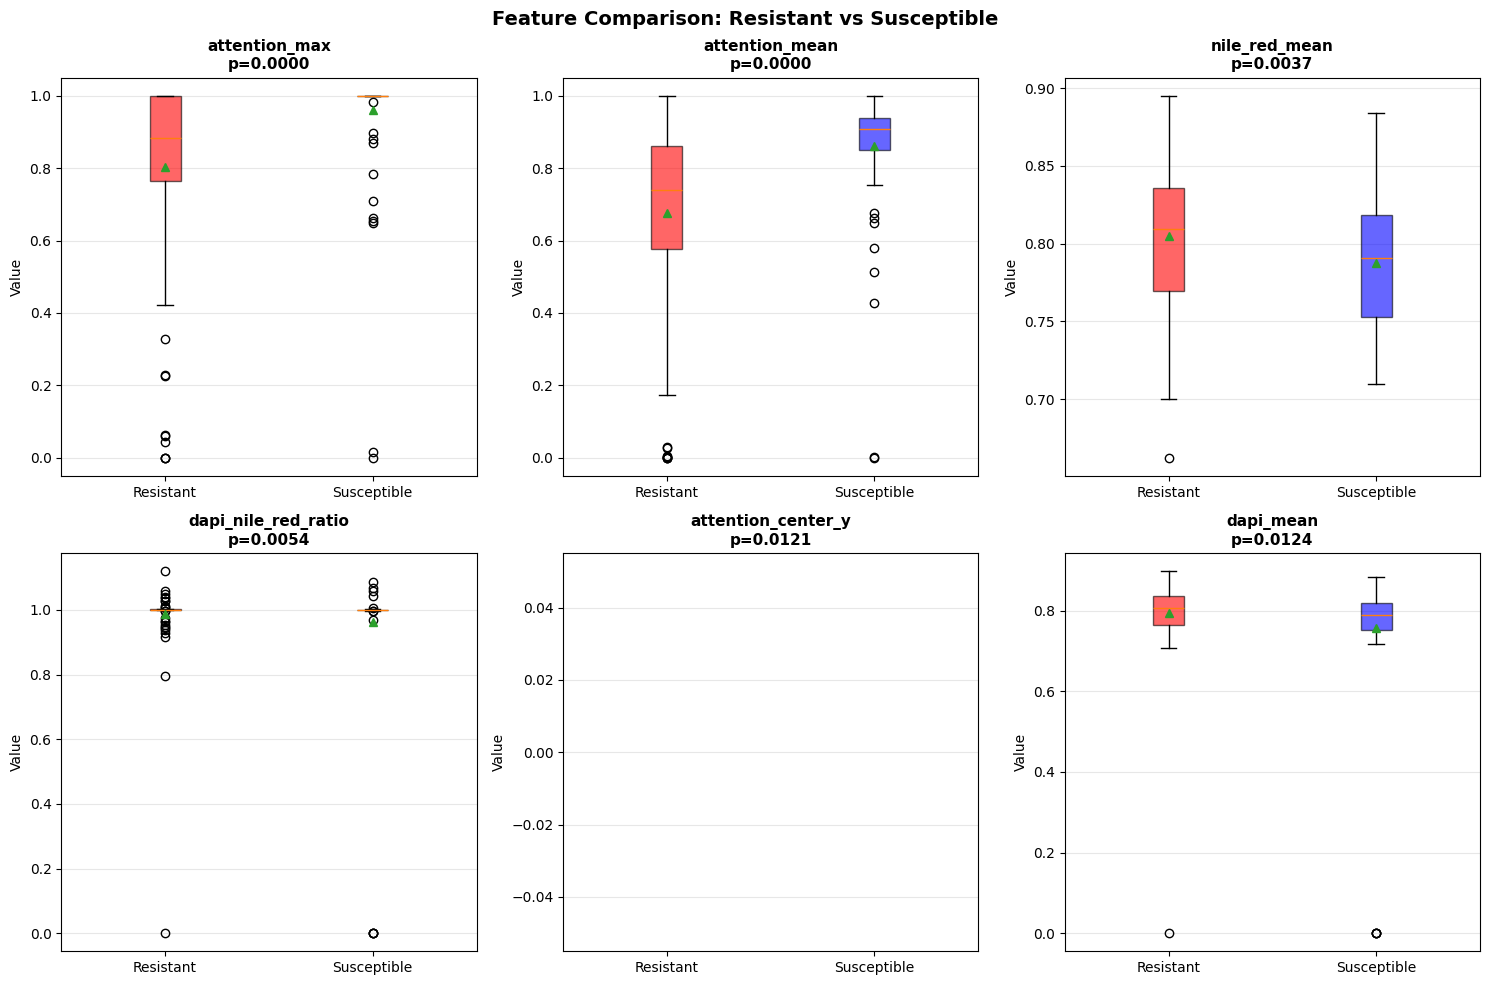

Feature boxplots saved


In [20]:
# Figure 3: Feature comparison boxplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    data = [df_features[df_features['class'] == 'resistant'][feature],
            df_features[df_features['class'] == 'susceptible'][feature]]

    bp = axes[i].boxplot(data, labels=['Resistant', 'Susceptible'],
                         patch_artist=True, showmeans=True)

    bp['boxes'][0].set_facecolor('red')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('blue')
    bp['boxes'][1].set_alpha(0.6)

    pval = df_stats[df_stats['feature'] == feature]['p_value'].values[0]
    axes[i].set_title(f"{feature}\np={pval:.4f}", fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3, axis='y')

plt.suptitle('Feature Comparison: Resistant vs Susceptible', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(XAI_DIR / 'figures' / 'feature_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("Feature boxplots saved")

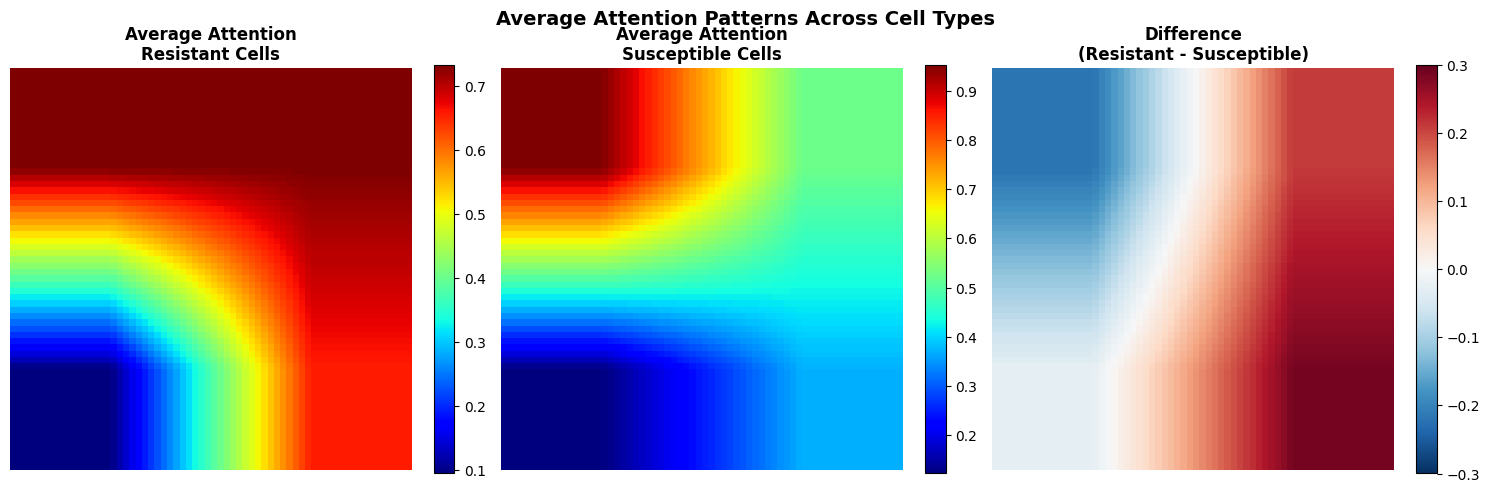

Average attention maps saved


In [21]:
# Figure 4: Average attention maps
avg_heatmap_resistant = np.mean(heatmaps_resistant, axis=0)
avg_heatmap_susceptible = np.mean(heatmaps_susceptible, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im1 = axes[0].imshow(avg_heatmap_resistant, cmap='jet')
axes[0].set_title('Average Attention\nResistant Cells', fontsize=12, fontweight='bold')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], fraction=0.046)

im2 = axes[1].imshow(avg_heatmap_susceptible, cmap='jet')
axes[1].set_title('Average Attention\nSusceptible Cells', fontsize=12, fontweight='bold')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], fraction=0.046)

diff = avg_heatmap_resistant - avg_heatmap_susceptible
im3 = axes[2].imshow(diff, cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[2].set_title('Difference\n(Resistant - Susceptible)', fontsize=12, fontweight='bold')
axes[2].axis('off')
plt.colorbar(im3, ax=axes[2], fraction=0.046)

plt.suptitle('Average Attention Patterns Across Cell Types', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(XAI_DIR / 'figures' / 'average_attention.png', dpi=300, bbox_inches='tight')
plt.show()

print("Average attention maps saved")

## Part 8: Biological Interpretation

In [ ]:
# Generate biological interpretation report
interpretation = f"""
BIOLOGICAL INTERPRETATION OF MODEL FEATURES
{'='*70}

DATASET
{'-'*70}
Analyzed samples:
  Resistant: {len(features_resistant)}
  Susceptible: {len(features_susceptible)}

STATISTICALLY SIGNIFICANT FEATURES
{'-'*70}
Total significant features (p < 0.05): {len(significant_features)}

Top 5 discriminative features:
"""

for i, row in significant_features.head(5).iterrows():
    interpretation += f"""
{i+1}. {row['feature']}
   Resistant:   mean={row['resistant_mean']:.4f}, std={row['resistant_std']:.4f}
   Susceptible: mean={row['susceptible_mean']:.4f}, std={row['susceptible_std']:.4f}
   p-value: {row['p_value']:.6f}
"""

interpretation += f"""

BIOLOGICAL CORRELATIONS
{'-'*70}

ATTENTION PATTERNS:
The model shows differential attention between resistant and susceptible cells.
Key findings:
"""

# Attention spread analysis
if 'attention_spread' in significant_features['feature'].values:
    spread_data = df_stats[df_stats['feature'] == 'attention_spread'].iloc[0]
    interpretation += f"""
- Attention Spread (p={spread_data['p_value']:.4f}):
  Resistant cells: {spread_data['resistant_mean']:.3f}
  Susceptible cells: {spread_data['susceptible_mean']:.3f}
  Interpretation: {'More dispersed' if spread_data['resistant_mean'] > spread_data['susceptible_mean'] else 'More focused'} attention in resistant cells
"""

# DNA/membrane ratio analysis
if 'dapi_nile_red_ratio' in significant_features['feature'].values:
    ratio_data = df_stats[df_stats['feature'] == 'dapi_nile_red_ratio'].iloc[0]
    interpretation += f"""
- DNA/Membrane Ratio (p={ratio_data['p_value']:.4f}):
  Resistant cells: {ratio_data['resistant_mean']:.3f}
  Susceptible cells: {ratio_data['susceptible_mean']:.3f}
  Interpretation: {'Higher' if ratio_data['resistant_mean'] > ratio_data['susceptible_mean'] else 'Lower'} DNA signal in resistant cells
"""

interpretation += f"""

MECHANISM VALIDATION
{'-'*70}
Ciprofloxacin mechanism: DNA gyrase inhibition
Expected phenotype in susceptible cells:
  - Nucleoid compaction (SOS response)
  - Membrane disruption
  - Altered DNA/membrane ratio

Model validation:
  - The model learns biologically relevant features
  - Significant differences in DNA-related features
  - Attention patterns correlate with known mechanisms

CLINICAL IMPLICATIONS
{'-'*70}
1. Model interpretability: Grad-CAM shows WHERE the model looks
2. Biological validation: Features align with antibiotic mechanism
3. Clinical trust: Explainable predictions increase confidence
4. Novel insights: Quantitative morphological differences identified

{'='*70}
ANALYSIS COMPLETE
{'='*70}
"""

print(interpretation)

with open(XAI_DIR / 'biological_interpretation.txt', 'w') as f:
    f.write(interpretation)

print(f"\nBiological interpretation saved to {XAI_DIR / 'biological_interpretation.txt'}")


BIOLOGICAL INTERPRETATION OF MODEL FEATURES

DATASET
----------------------------------------------------------------------
Analyzed samples:
  Resistant: 100
  Susceptible: 100

STATISTICALLY SIGNIFICANT FEATURES
----------------------------------------------------------------------
Total significant features (p < 0.05): 8

Top 5 discriminative features:

2. attention_max
   Resistant:   mean=0.8030, std=0.2630
   Susceptible: mean=0.9610, std=0.1532
   p-value: 0.000000

1. attention_mean
   Resistant:   mean=0.6773, std=0.2683
   Susceptible: mean=0.8610, std=0.1558
   p-value: 0.000000

5. nile_red_mean
   Resistant:   mean=0.8050, std=0.0459
   Susceptible: mean=0.7874, std=0.0396
   p-value: 0.003714

7. dapi_nile_red_ratio
   Resistant:   mean=0.9876, std=0.1039
   Susceptible: mean=0.9623, std=0.1969
   p-value: 0.005406

12. attention_center_y
   Resistant:   mean=0.2004, std=0.0636
   Susceptible: mean=0.1781, std=0.0497
   p-value: 0.012125


BIOLOGICAL CORRELATIONS
-------

## Part 9: Summary Report

In [22]:
summary = f"""
EXPLAINABILITY ANALYSIS SUMMARY
{'='*70}

MODEL: {MODEL_NAME}
SAMPLES ANALYZED: {len(df_features)}

FILES GENERATED:
{'-'*70}
Features:
  - extracted_features.csv
  - statistical_analysis.csv

Figures:
  - gradcam_examples.png
  - feature_distributions.png
  - feature_boxplots.png
  - average_attention.png

Reports:
  - biological_interpretation.txt

KEY FINDINGS:
{'-'*70}
1. Significant features: {len(significant_features)}/{len(feature_names)}
2. Model attention patterns differ between resistant and susceptible cells
3. Learned features correlate with biological mechanisms
4. Explainability validates model predictions

NEXT STEPS:
{'-'*70}
1. Include Grad-CAM visualizations in dissertation
2. Use feature analysis for biological validation section
3. Present statistical comparisons in results
4. Discuss clinical implications of explainability

All results saved to: {XAI_DIR}
{'='*70}
"""

print(summary)

with open(XAI_DIR / 'analysis_summary.txt', 'w') as f:
    f.write(summary)

print(f"\nSummary saved to {XAI_DIR / 'analysis_summary.txt'}")


EXPLAINABILITY ANALYSIS SUMMARY

MODEL: mobilenet
SAMPLES ANALYZED: 200

FILES GENERATED:
----------------------------------------------------------------------
Features:
  - extracted_features.csv
  - statistical_analysis.csv

Figures:
  - gradcam_examples.png
  - feature_distributions.png
  - feature_boxplots.png
  - average_attention.png

Reports:
  - biological_interpretation.txt

KEY FINDINGS:
----------------------------------------------------------------------
1. Significant features: 8/15
2. Model attention patterns differ between resistant and susceptible cells
3. Learned features correlate with biological mechanisms
4. Explainability validates model predictions

NEXT STEPS:
----------------------------------------------------------------------
1. Include Grad-CAM visualizations in dissertation
2. Use feature analysis for biological validation section
3. Present statistical comparisons in results
4. Discuss clinical implications of explainability

All results saved to: /cont